# Data Pre-processing Techniques


In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


1. Feature Scaling

In [6]:
x1=np.random.randint(1,20,size=(20,1))
x2=np.random.randint(10,200,size=(20,1))
x3=np.random.randint(100,2000,size=(20,1))
X=np.concatenate((x1,x2,x3),axis=1)
X

array([[   1,  111, 1352],
       [   7,   99, 1167],
       [  15,  197, 1433],
       [   9,   92, 1338],
       [   3,  170, 1813],
       [  16,   74,  364],
       [  10,   73,  334],
       [   9,  170, 1056],
       [   4,   42, 1654],
       [  19,  145,  570],
       [   3,  170,  620],
       [  10,   30,  867],
       [   1,   91,  845],
       [  17,   99, 1829],
       [   1,  149,  452],
       [  16,   27, 1822],
       [  18,  130, 1254],
       [  10,   35,  947],
       [   6,   49,  591],
       [   5,   44,  489]], dtype=int32)

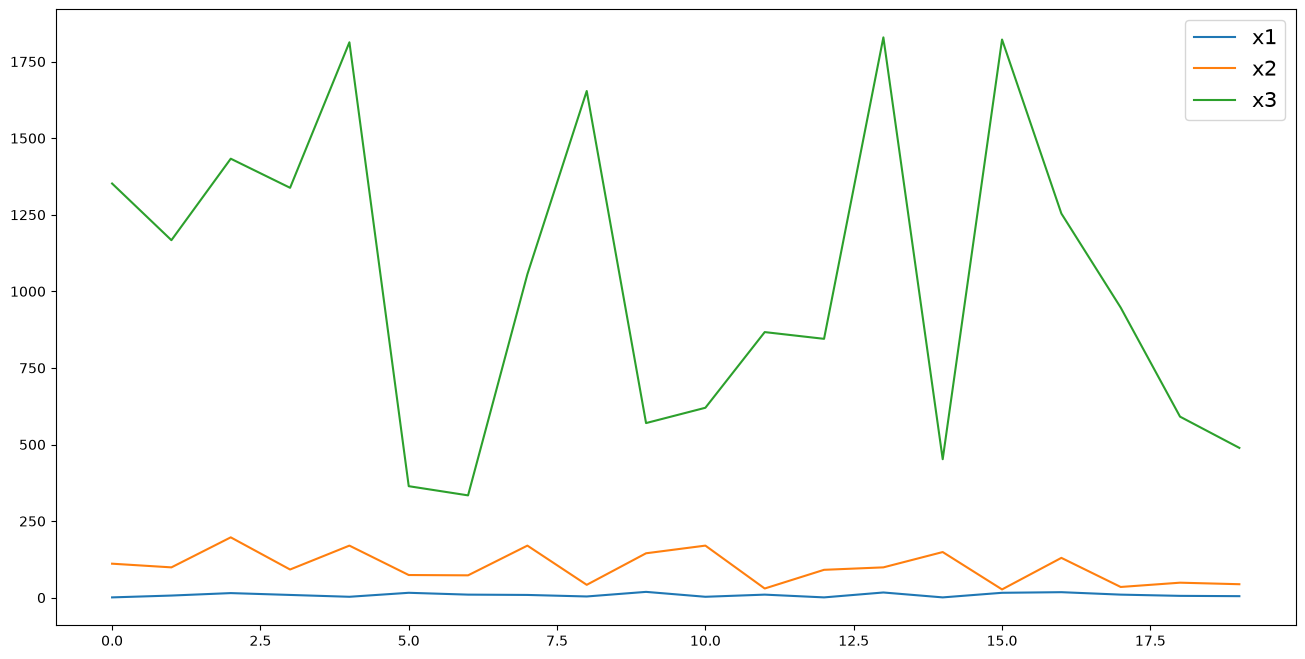

In [9]:
plt.figure(figsize=(16,8))
plt.plot(x1)
plt.plot(x2)
plt.plot(x3)
plt.legend(['x1','x2','x3'],fontsize=15)
plt.show()

In [10]:
X.mean(axis=0)

array([   9.  ,   99.85, 1039.85])

In [11]:
X.mean(axis=1)

array([488.        , 424.33333333, 548.33333333, 479.66666667,
       662.        , 151.33333333, 139.        , 411.66666667,
       566.66666667, 244.66666667, 264.33333333, 302.33333333,
       312.33333333, 648.33333333, 200.66666667, 621.66666667,
       467.33333333, 330.66666667, 215.33333333, 179.33333333])

In [12]:
X.std(axis=0)

array([  5.91607978,  52.27932192, 494.55073299])

## 1. Normalization ##

In [13]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
mm.fit(X)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[ 19., 197.,1829.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[ 1., 27.,334.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[ 18., 170.,1495.]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.06,-0.16,-0.22]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,20
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](3,)","[0.06,0.01,0. ]"


In [14]:
X_norm=mm.transform(X)
X_norm

array([[0.        , 0.49411765, 0.68093645],
       [0.33333333, 0.42352941, 0.55719064],
       [0.77777778, 1.        , 0.73511706],
       [0.44444444, 0.38235294, 0.67157191],
       [0.11111111, 0.84117647, 0.98929766],
       [0.83333333, 0.27647059, 0.02006689],
       [0.5       , 0.27058824, 0.        ],
       [0.44444444, 0.84117647, 0.48294314],
       [0.16666667, 0.08823529, 0.88294314],
       [1.        , 0.69411765, 0.15785953],
       [0.11111111, 0.84117647, 0.19130435],
       [0.5       , 0.01764706, 0.35652174],
       [0.        , 0.37647059, 0.34180602],
       [0.88888889, 0.42352941, 1.        ],
       [0.        , 0.71764706, 0.07892977],
       [0.83333333, 0.        , 0.99531773],
       [0.94444444, 0.60588235, 0.61538462],
       [0.5       , 0.04705882, 0.41003344],
       [0.27777778, 0.12941176, 0.17190635],
       [0.22222222, 0.1       , 0.10367893]])

In [15]:
X_norm.mean(axis=0)

array([0.44444444, 0.42852941, 0.47214047])

In [16]:
X_norm.mean(axis=1)

array([0.3916847 , 0.43801779, 0.83763161, 0.49945643, 0.64719508,
       0.3766236 , 0.25686275, 0.58952135, 0.3792817 , 0.61732573,
       0.38119731, 0.2913896 , 0.23942554, 0.7708061 , 0.26552561,
       0.60955035, 0.7219038 , 0.31903076, 0.19303197, 0.14196705])

# 2. Standardization

In [17]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(X)

StandardScaler()

In [18]:
X_standardized=ss.transform(X)
X_standardized

array([[-1.35224681,  0.21327744,  0.63117892],
       [-0.3380617 , -0.01625882,  0.25710204],
       [ 1.01418511,  1.8582873 ,  0.79496394],
       [ 0.        , -0.15015497,  0.6028704 ],
       [-1.01418511,  1.34183072,  1.56333809],
       [ 1.18321596, -0.49445936, -1.36659387],
       [ 0.16903085, -0.51358738, -1.42725499],
       [ 0.        ,  1.34183072,  0.0326559 ],
       [-0.84515425, -1.10655605,  1.24183417],
       [ 1.69030851,  0.86363018, -0.9500542 ],
       [-1.01418511,  1.34183072, -0.84895234],
       [ 0.16903085, -1.33609231, -0.34950914],
       [-1.35224681, -0.16928299, -0.39399396],
       [ 1.35224681, -0.01625882,  1.59569069],
       [-1.35224681,  0.94014226, -1.18865459],
       [ 1.18321596, -1.39347638,  1.58153643],
       [ 1.52127766,  0.57670985,  0.43301928],
       [ 0.16903085, -1.2404522 , -0.18774616],
       [-0.50709255, -0.9726599 , -0.90759142],
       [-0.6761234 , -1.06830001, -1.11383921]])

In [19]:
X_standardized.mean(axis=0)

array([1.11022302e-17, 5.55111512e-17, 1.55431223e-16])

In [20]:
X_standardized.mean()

np.float64(1.0362081563168128e-16)

# 2. Data Imputation

In [22]:
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(missing_values=-1 , strategy='mean')


In [24]:
X1=np.array([[1,2,3],[6,0,-1],[3,-1,4]])
X1

array([[ 1,  2,  3],
       [ 6,  0, -1],
       [ 3, -1,  4]])

In [25]:
imputer=imputer.fit(X1)

In [26]:
X1_imputed=imputer.transform(X1)
X1_imputed

array([[1. , 2. , 3. ],
       [6. , 0. , 3.5],
       [3. , 1. , 4. ]])

In [27]:
X2 = np.array([['France', 44.0, 72000.0],
       ['Spain', 27.0, 48000.0],
       ['Germany', 30.0, 54000.0],
       ['Spain', 38.0, 61000.0],
       ['Germany', 40.0, np.nan],
       ['France', 35.0, 58000.0],
       ['Spain', np.nan, 52000.0],
       ['France', 48.0, 79000.0],
       ['Germany', 50.0, 83000.0],
       ['France', 37.0, 67000.0]])
X2

array([['France', '44.0', '72000.0'],
       ['Spain', '27.0', '48000.0'],
       ['Germany', '30.0', '54000.0'],
       ['Spain', '38.0', '61000.0'],
       ['Germany', '40.0', 'nan'],
       ['France', '35.0', '58000.0'],
       ['Spain', 'nan', '52000.0'],
       ['France', '48.0', '79000.0'],
       ['Germany', '50.0', '83000.0'],
       ['France', '37.0', '67000.0']], dtype='<U32')

In [33]:
imputer2=SimpleImputer(missing_values=np.nan, strategy='mean')
imputer2=imputer2.fit(X2[:,1:3])

In [34]:
X2[:,1:3]=imputer2.transform(X2[:,1:3])

In [35]:
X2

array([['France', '44.0', '72000.0'],
       ['Spain', '27.0', '48000.0'],
       ['Germany', '30.0', '54000.0'],
       ['Spain', '38.0', '61000.0'],
       ['Germany', '40.0', '63777.77777777778'],
       ['France', '35.0', '58000.0'],
       ['Spain', '38.77777777777778', '52000.0'],
       ['France', '48.0', '79000.0'],
       ['Germany', '50.0', '83000.0'],
       ['France', '37.0', '67000.0']], dtype='<U32')

Another Example

In [36]:
X3 = np.array([[46, 'F', 'US'], [65, 'M', 'Canada'], [35, 'F','India'], [-2, 'M', 'Australia'], [49, 'M', 'Netherlands'], [-2, 'F', 'South Africa']])
X3

array([['46', 'F', 'US'],
       ['65', 'M', 'Canada'],
       ['35', 'F', 'India'],
       ['-2', 'M', 'Australia'],
       ['49', 'M', 'Netherlands'],
       ['-2', 'F', 'South Africa']], dtype='<U21')

In [40]:
imputer3=SimpleImputer(missing_values=-2 , strategy='mean')
imputer3=imputer3.fit(X3[:,0].reshape(-1,1))

In [41]:
X3[:,0:1] =imputer3.transform(X3[:,0].reshape(-1,1))

3. Handling Categorical Features 

One Hot Encoding

In [43]:
from sklearn.preprocessing import OneHotEncoder

In [44]:
X_cat=np.array([['red'],['green'],['blue']])
X_cat

array([['red'],
       ['green'],
       ['blue']], dtype='<U5')

In [56]:
ohe = OneHotEncoder(sparse_output=False)
encoded_X_cat=ohe.fit_transform(X_cat)
encoded_X_cat


array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

Example 2


In [53]:
X_cat2=np.array([[46, 'F', 'US'], [65, 'M', 'Canada'], [35, 'F','India'], [37, 'M', 'Australia'], [49, 'M', 'Netherlands'], [73, 'F', 'South Africa']])

In [55]:
ohe=OneHotEncoder(sparse_output=False)
encoded_country_feature=ohe.fit_transform(X_cat2[:,2:3])
encoded_country_feature

array([[0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [58]:
encoded_X_cat2=np.concatenate((X_cat2[:,0:1],X_cat2[:,1:2],encoded_country_feature),axis=1)
encoded_X_cat2

array([['46', 'F', '0.0', '0.0', '0.0', '0.0', '0.0', '1.0'],
       ['65', 'M', '0.0', '1.0', '0.0', '0.0', '0.0', '0.0'],
       ['35', 'F', '0.0', '0.0', '1.0', '0.0', '0.0', '0.0'],
       ['37', 'M', '1.0', '0.0', '0.0', '0.0', '0.0', '0.0'],
       ['49', 'M', '0.0', '0.0', '0.0', '1.0', '0.0', '0.0'],
       ['73', 'F', '0.0', '0.0', '0.0', '0.0', '1.0', '0.0']],
      dtype='<U32')

4. Handling imbalanced data